<p align="center">
  <img src="https://www.portafolio.co/files/article_new_multimedia/uploads/2023/10/12/652828e536642.jpeg" style="width:100%; max-width:900px; height:180px; object-fit:cover; border-radius:10px;"/>
</p>
<div style="text-align:center;">
  <h1 style="color:#FFD700; display:inline-block; margin:0;">Optimización del Transporte en Nueva York</h1>
  <p>
    <b>Green Taxi | Machine Learning & Data Science | CRISP-DM</b><br>
    <span style="font-size:1.1em;">Análisis y predicción de tarifas y duración de viajes usando datos reales de taxis verdes de NYC.</span>
  </p>
</div>

In [1]:
# Verifica si las librerías necesarias ya están instaladas
try:
    # Ignorar warnings
    import warnings
    warnings.filterwarnings('ignore')

    # Librerías del sistema
    import sys, subprocess

    # Importaciones base
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import os
    import joblib
    import scipy.stats as stats
    import pickle as pkl

    # Librerías de codificación y progreso
    import category_encoders as ce
    from tqdm import tqdm   

    # Librerías de preprocesamiento
    from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
    from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
    from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier)
    from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
    from sklearn.svm import SVC, SVR
    from sklearn.naive_bayes import GaussianNB
    from sklearn.neural_network import MLPRegressor, MLPClassifier
    from sklearn.preprocessing import (StandardScaler, MinMaxScaler, RobustScaler, PolynomialFeatures)
    from sklearn.impute import SimpleImputer, KNNImputer
    from sklearn.pipeline import make_pipeline
    from sklearn.model_selection import (train_test_split, GridSearchCV,RandomizedSearchCV, cross_val_score, cross_val_predict)
    from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,confusion_matrix, classification_report, roc_auc_score, roc_curve, calinski_harabasz_score)
    
    # Establece el tema global
    sns.set_theme(
    style="whitegrid",                  # El estilo del gráfico (fondo y cuadrícula)
        palette="colorblind",           # La paleta de colores
        font="sans-serif",               # La familia de la fuente
        font_scale=0.9,                  # Escala de la fuente
        rc={"axes.titlesize": 14, "axes.labelsize": 12, "xtick.labelsize": 10, "ytick.labelsize": 10}
    )
    
    print("Dependencias ya instaladas.")

except ImportError:

    print("Dependencias no encontradas. Instalando ahora...")
    
    # Se ejecutan los comandos de instalación
    %pip install --quiet matplotlib
    %pip install --quiet seaborn
    %pip install --quiet joblib
    %pip install --quiet scipy
    %pip install --quiet category_encoders
    %pip install --quiet tqdm
    
    print("Instalación completada.")

Dependencias ya instaladas.


In [2]:
# Función lambda para verificar e instalar
instalar = lambda p: subprocess.call([sys.executable, "-c", f"import {p}"]) and subprocess.call([sys.executable, "-m", "pip", "install", p, "-q"])

# Actualizar pip
subprocess.call([sys.executable, "-m", "pip", "install", "--upgrade", "pip", "-q"])

# Verificar e instalar condicionalmente
if instalar("pyarrow") == 0: print("PyArrow instalado/verificado")
if instalar("fastparquet") == 0: print("FastParquet instalado/verificado")

print("Listo para usar")

PyArrow instalado/verificado
FastParquet instalado/verificado
Listo para usar
FastParquet instalado/verificado
Listo para usar


# 04.- Modeling

In [3]:
# Configuración del dataset desde el directorio local
parquet_file = "modeling_green_tripdata_2025-06.parquet"
# Cargar el dataset de modelado
df_modeling = pd.read_parquet(parquet_file, engine="pyarrow")

print("Dataset Cargado.")

Dataset Cargado.


## Fare Amount Modeling 

In [4]:
# Objetivo
target_variable = 'fare_amount'
# Exclusión de variables
exclude_cols = [target_variable, 'fare_amount'] 
features = [col for col in df_modeling.select_dtypes(include=np.number).columns if col not in exclude_cols]
# División de datos
X = df_modeling[features]
y = df_modeling[target_variable]

print(f"Características seleccionadas para el modelado.")

Características seleccionadas para el modelado.


In [5]:
# División de datos en entrenamiento y prueba (70% - 30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Datos divididos en conjuntos de entrenamiento y prueba.")

Datos divididos en conjuntos de entrenamiento y prueba.


In [6]:
# Importar modelos adicionales
from sklearn.linear_model import Lasso
from sklearn.neural_network import MLPRegressor

# Crear instancias de los modelos
# Linear
lr = LinearRegression()
#pf = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression()) 
# Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
dt = DecisionTreeRegressor(random_state=42)
# Knn
knn = KNeighborsRegressor(n_neighbors=5, n_jobs=-1) # k=5 es un punto de partida común
ridge = Ridge(random_state=42)
lasso = Lasso(random_state=42)
# otros
#xgboost = GradientBoostingRegressor(random_state=42)
#svr = SVR(kernel='rbf', C=1.0)
neural_network = MLPRegressor(hidden_layer_sizes=(100,), random_state=42, max_iter=500)

# Definicion del diccionario de los modelos.
models_regression = {
    'LinearRegression': lr,
    #'PolynomialFeatures_LR': pf, 
    'RandomForest': rf,
    'DecisionTree': dt,
    'KNeighbors': knn,
    'Ridge': ridge,
    'Lasso': lasso,
    #'XGBoost': xgboost,
    #'SVR': svr,
    'NeuralNetwork': neural_network
}

print("Diccionario de modelos creado.")

Diccionario de modelos creado.


In [7]:
# Manejo de valores faltantes
# !!! Error de no tratamiento de valores faltantes ¡¡¡
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)
# !!! Error de no tratamiento de valores faltantes ¡¡¡

# Diccionario para almacenar resultados de métricas.
test_metrics_results = {}
# Ciclo de entrenamiento y evaluación de modelos
for name, model in models_regression.items():
    # Ajustar el modelo y hacer predicciones
    model.fit(X_train_imputed, y_train)
    y_pred_test = model.predict(X_test_imputed)

    # Calcular métricas en el set de prueba
    mae = mean_absolute_error(y_test, y_pred_test)
    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred_test)

    # Almacenar resultados del set de prueba
    test_metrics_results[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2
    }
    
    print(f"Evaluación completada para {name}.")

Evaluación completada para LinearRegression.
Evaluación completada para RandomForest.
Evaluación completada para RandomForest.
Evaluación completada para DecisionTree.
Evaluación completada para DecisionTree.
Evaluación completada para KNeighbors.
Evaluación completada para Ridge.
Evaluación completada para Lasso.
Evaluación completada para KNeighbors.
Evaluación completada para Ridge.
Evaluación completada para Lasso.
Evaluación completada para NeuralNetwork.
Evaluación completada para NeuralNetwork.


In [8]:
# Mostrar Tabla de Comparación (Set de Prueba)
comparison_test_df = pd.DataFrame(test_metrics_results).T
# Imprimir la tabla en formato legible
print("\nTabla Comparativa de Métricas (Set de Prueba)")
print("---") # Separador Markdown
# Formato tabular para la impresión del DataFrame
print(f"{'Modelo':<20} | {'MAE':>12} | {'MSE':>12} | {'RMSE':>12} | {'R²':>10}")
print("-" * (20 + 3 + 12 + 3 + 12 + 3 + 12 + 3 + 10 + 2)) # Ajusta guiones
for index, row in comparison_test_df.sort_values(by='RMSE').iterrows(): # Ordenar por RMSE
    print(f"{index:<20} | {row['MAE']:>12.4f} | {row['MSE']:>12.4f} | {row['RMSE']:>12.4f} | {row['R²']:>10.4f}")
print("-" * (20 + 3 + 12 + 3 + 12 + 3 + 12 + 3 + 10 + 2))
print("---") # Separador Markdown


Tabla Comparativa de Métricas (Set de Prueba)
---
Modelo               |          MAE |          MSE |         RMSE |         R²
--------------------------------------------------------------------------------
RandomForest         |       0.4403 |       2.2362 |       1.4954 |     0.9932
DecisionTree         |       0.5947 |       2.6658 |       1.6327 |     0.9919
Ridge                |       0.8536 |       8.3541 |       2.8903 |     0.9747
LinearRegression     |       0.8536 |       8.3541 |       2.8904 |     0.9747
NeuralNetwork        |       1.5235 |       9.0476 |       3.0079 |     0.9726
Lasso                |       1.8640 |      14.0338 |       3.7462 |     0.9574
KNeighbors           |       2.9401 |      35.0320 |       5.9188 |     0.8937
--------------------------------------------------------------------------------
---


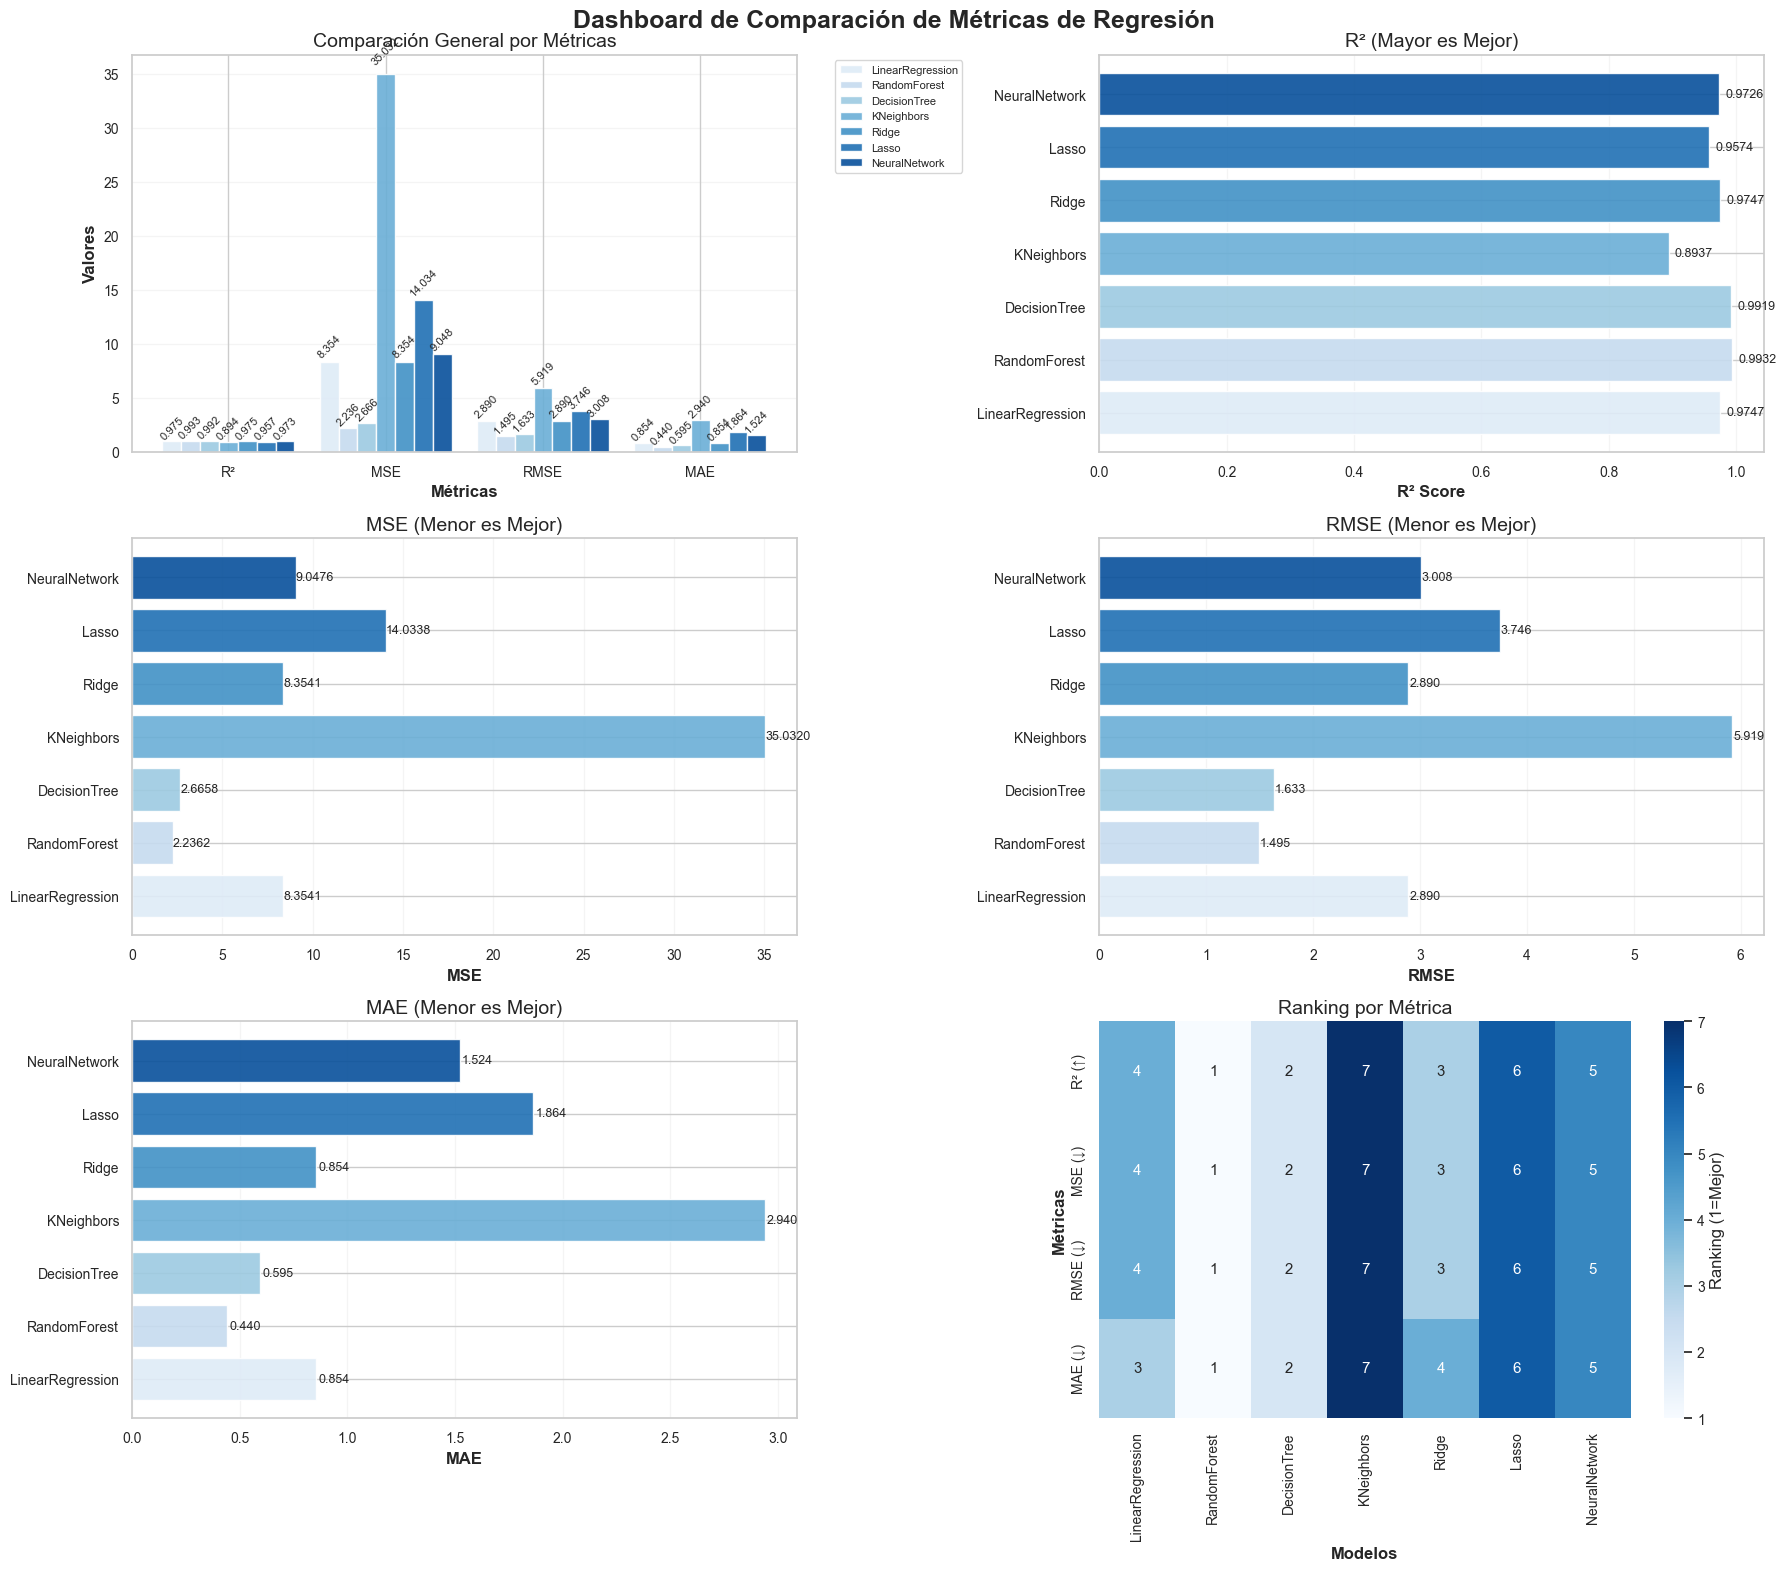

In [9]:
# Configurar figura con múltiples subplots (ahora 3x2 para gráficos individuales)
fig, axes = plt.subplots(3, 2, figsize=(18, 16), gridspec_kw={'height_ratios': [1, 1, 1]})
fig.suptitle('Dashboard de Comparación de Métricas de Regresión', fontsize=18, fontweight='bold')

# Preparar datos
models_names = list(test_metrics_results.keys())
# Paleta de Colores
colors = sns.color_palette("Blues", len(models_names))

# Barras comparativas Generales
ax1 = axes[0, 0]
metrics_reg = ['R²', 'MSE', 'RMSE', 'MAE']
x_pos = np.arange(len(metrics_reg))
width = 0.12

for i, (name, color) in enumerate(zip(models_names, colors)):
    values = [test_metrics_results[name][metric] for metric in metrics_reg]
    bars = ax1.bar(x_pos + i * width, values, width, label=name, color=color, alpha=0.9, edgecolor='white')
    
    # Etiquetas en barras
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.02, f'{val:.3f}', 
                 ha='center', va='bottom', fontsize=8, rotation=45)

ax1.set_xlabel('Métricas', fontweight='bold')
ax1.set_ylabel('Valores', fontweight='bold')
ax1.set_title('Comparación General por Métricas')
ax1.set_xticks(x_pos + width * (len(models_names) - 1) / 2)
ax1.set_xticklabels(metrics_reg, rotation=0)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.2, axis='y')

# Gráfico 02: R² Score
ax2 = axes[0, 1]
r2_scores = [test_metrics_results[name]['R²'] for name in models_names]
bars2 = ax2.barh(models_names, r2_scores, color=colors, alpha=0.9)
ax2.set_xlabel('R² Score', fontweight='bold')
ax2.set_title('R² (Mayor es Mejor)')
ax2.grid(True, alpha=0.2, axis='x')
for bar, score in zip(bars2, r2_scores):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{score:.4f}', 
             ha='left', va='center', fontsize=9)

# Gráfico 03: MSE 
ax3 = axes[1, 0]
mse_scores = [test_metrics_results[name]['MSE'] for name in models_names]
bars3 = ax3.barh(models_names, mse_scores, color=colors, alpha=0.9)
ax3.set_xlabel('MSE', fontweight='bold')
ax3.set_title('MSE (Menor es Mejor)')
ax3.grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars3, mse_scores):
    ax3.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
             ha='left', va='center', fontsize=9)

# Gráfico 04: RMSE
ax4 = axes[1, 1]
rmse_scores = [test_metrics_results[name]['RMSE'] for name in models_names]
bars4 = ax4.barh(models_names, rmse_scores, color=colors, alpha=0.9)
ax4.set_xlabel('RMSE', fontweight='bold')
ax4.set_title('RMSE (Menor es Mejor)')
ax4.grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars4, rmse_scores):
    ax4.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
             ha='left', va='center', fontsize=9)

# Gráfico 05: MAE
ax5 = axes[2, 0]
mae_scores = [test_metrics_results[name]['MAE'] for name in models_names]
bars5 = ax5.barh(models_names, mae_scores, color=colors, alpha=0.9)
ax5.set_xlabel('MAE', fontweight='bold')
ax5.set_title('MAE (Menor es Mejor)')
ax5.grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars5, mae_scores):
    ax5.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
             ha='left', va='center', fontsize=9)

# Gráfico 06: Heatmap
ax6 = axes[2, 1]
comparison_df = pd.DataFrame(test_metrics_results).T
ranking_matrix = []
for metric in metrics_reg:
    if metric == 'R²':
        ranked = comparison_df[metric].rank(ascending=False)
    else:
        ranked = comparison_df[metric].rank(ascending=True)
    ranking_matrix.append(ranked.values)

ranking_df = pd.DataFrame(ranking_matrix, index=[f'{m} {"(↑)" if m=="R²" else "(↓)"}' for m in metrics_reg], columns=models_names)

sns.heatmap(ranking_df, annot=True, fmt='.0f', cmap='Blues', ax=ax6, cbar_kws={'label': 'Ranking (1=Mejor)'})
ax6.set_title('Ranking por Métrica')
ax6.set_xlabel('Modelos', fontweight='bold')
ax6.set_ylabel('Métricas', fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:

# Resumen Mejorado con Ranking Promedio
print("\nResumen de los Mejores Modelos")
best_models = {}
for metric in metrics_reg:
    if metric == 'R²':
        best = max(test_metrics_results.items(), key=lambda x: x[1][metric])
    else:
        best = min(test_metrics_results.items(), key=lambda x: x[1][metric])
    print(f"Mejor {metric:>4} {'(Mayor)':<7}: {best[0]:<20} = {best[1][metric]:.4f}")
    best_models[metric] = best[0]

# Ranking Promedio
avg_ranks = ranking_df.mean().sort_values()
print("\nRanking Promedio (Menor = Mejor General):")
for model, rank in avg_ranks.items():
    print(f"{model:<20}: {rank:.2f}")


REsumen de los Mejores Modelos
Mejor   R² (Mayor): RandomForest         = 0.9932
Mejor  MSE (Mayor): RandomForest         = 2.2362
Mejor RMSE (Mayor): RandomForest         = 1.4954
Mejor  MAE (Mayor): RandomForest         = 0.4403

Ranking Promedio (Menor = Mejor General):
RandomForest        : 1.00
DecisionTree        : 2.00
Ridge               : 3.25
LinearRegression    : 3.75
NeuralNetwork       : 5.00
Lasso               : 6.00
KNeighbors          : 7.00


## Trip Duration in Minutes

In [11]:
target_variable = 'trip_duration_min'

exclude_cols = [target_variable, 'fare_amount'] 
features = [col for col in df_modeling.select_dtypes(include=np.number).columns if col not in exclude_cols]

X = df_modeling[features]
y = df_modeling[target_variable]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [13]:
# Importar modelos adicionales
from sklearn.linear_model import Lasso
from sklearn.neural_network import MLPRegressor

# Crear instancias de los modelos
# Linear
lr = LinearRegression()
#pf = make_pipeline(PolynomialFeatures(degree=2, include_bias=False), LinearRegression()) 
# Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
dt = DecisionTreeRegressor(random_state=42)
# Knn
knn = KNeighborsRegressor(n_neighbors=5, n_jobs=-1) # k=5 es un punto de partida común
ridge = Ridge(random_state=42)
lasso = Lasso(random_state=42)
# otros
#xgboost = GradientBoostingRegressor(random_state=42)
#svr = SVR(kernel='rbf', C=1.0)
neural_network = MLPRegressor(hidden_layer_sizes=(100,), random_state=42, max_iter=500)

# Definicion del diccionario de los modelos.
models_regression = {
    'LinearRegression': lr,
    #'PolynomialFeatures_LR': pf, 
    'RandomForest': rf,
    'DecisionTree': dt,
    'KNeighbors': knn,
    'Ridge': ridge,
    'Lasso': lasso,
    #'XGBoost': xgboost,
    #'SVR': svr,
    'NeuralNetwork': neural_network
}

print("Diccionario de modelos creado.")

Diccionario de modelos creado.


In [14]:
# Manejo de valores faltantes
# !!! Error de no tratamiento de valores faltantes ¡¡¡
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)
# !!! Error de no tratamiento de valores faltantes ¡¡¡

# Diccionario para almacenar resultados de métricas.
test_metrics_results = {}
# Ciclo de entrenamiento y evaluación de modelos
for name, model in models_regression.items():
    # Ajustar el modelo y hacer predicciones
    model.fit(X_train_imputed, y_train)
    y_pred_test = model.predict(X_test_imputed)

    # Calcular métricas en el set de prueba
    mae = mean_absolute_error(y_test, y_pred_test)
    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred_test)

    # Almacenar resultados del set de prueba
    test_metrics_results[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R²': r2
    }
    
    print(f"Evaluación completada para {name}.")

Evaluación completada para LinearRegression.
Evaluación completada para RandomForest.
Evaluación completada para RandomForest.
Evaluación completada para DecisionTree.
Evaluación completada para DecisionTree.
Evaluación completada para KNeighbors.
Evaluación completada para Ridge.
Evaluación completada para Lasso.
Evaluación completada para KNeighbors.
Evaluación completada para Ridge.
Evaluación completada para Lasso.
Evaluación completada para NeuralNetwork.
Evaluación completada para NeuralNetwork.


In [15]:
# 6. Mostrar Tabla de Comparación (Set de Prueba)
comparison_test_df = pd.DataFrame(test_metrics_results).T # Transponer
print("\nTabla Comparativa de Métricas (Set de Prueba)")
print("---") # Separador Markdown

# Formato tabular para la impresión del DataFrame
print(f"{'Modelo':<20} | {'MAE':>12} | {'MSE':>12} | {'RMSE':>12} | {'R²':>10}")
print("-" * (20 + 3 + 12 + 3 + 12 + 3 + 12 + 3 + 10 + 2)) # Ajusta guiones
for index, row in comparison_test_df.sort_values(by='RMSE').iterrows(): # Ordenar por RMSE
    print(f"{index:<20} | {row['MAE']:>12.4f} | {row['MSE']:>12.4f} | {row['RMSE']:>12.4f} | {row['R²']:>10.4f}")
print("-" * (20 + 3 + 12 + 3 + 12 + 3 + 12 + 3 + 10 + 2))
print("---") # Separador Markdown


Tabla Comparativa de Métricas (Set de Prueba)
---
Modelo               |          MAE |          MSE |         RMSE |         R²
--------------------------------------------------------------------------------
Ridge                |      10.5574 |    4632.6413 |      68.0635 |     0.0164
LinearRegression     |      10.5579 |    4632.6439 |      68.0635 |     0.0164
Lasso                |      10.7015 |    4643.5563 |      68.1436 |     0.0141
NeuralNetwork        |       9.0296 |    4724.1533 |      68.7325 |    -0.0030
RandomForest         |      11.8969 |    5142.6387 |      71.7122 |    -0.0919
KNeighbors           |      12.6910 |    5788.8564 |      76.0845 |    -0.2291
DecisionTree         |      12.8826 |   12203.5282 |     110.4696 |    -1.5910
--------------------------------------------------------------------------------
---


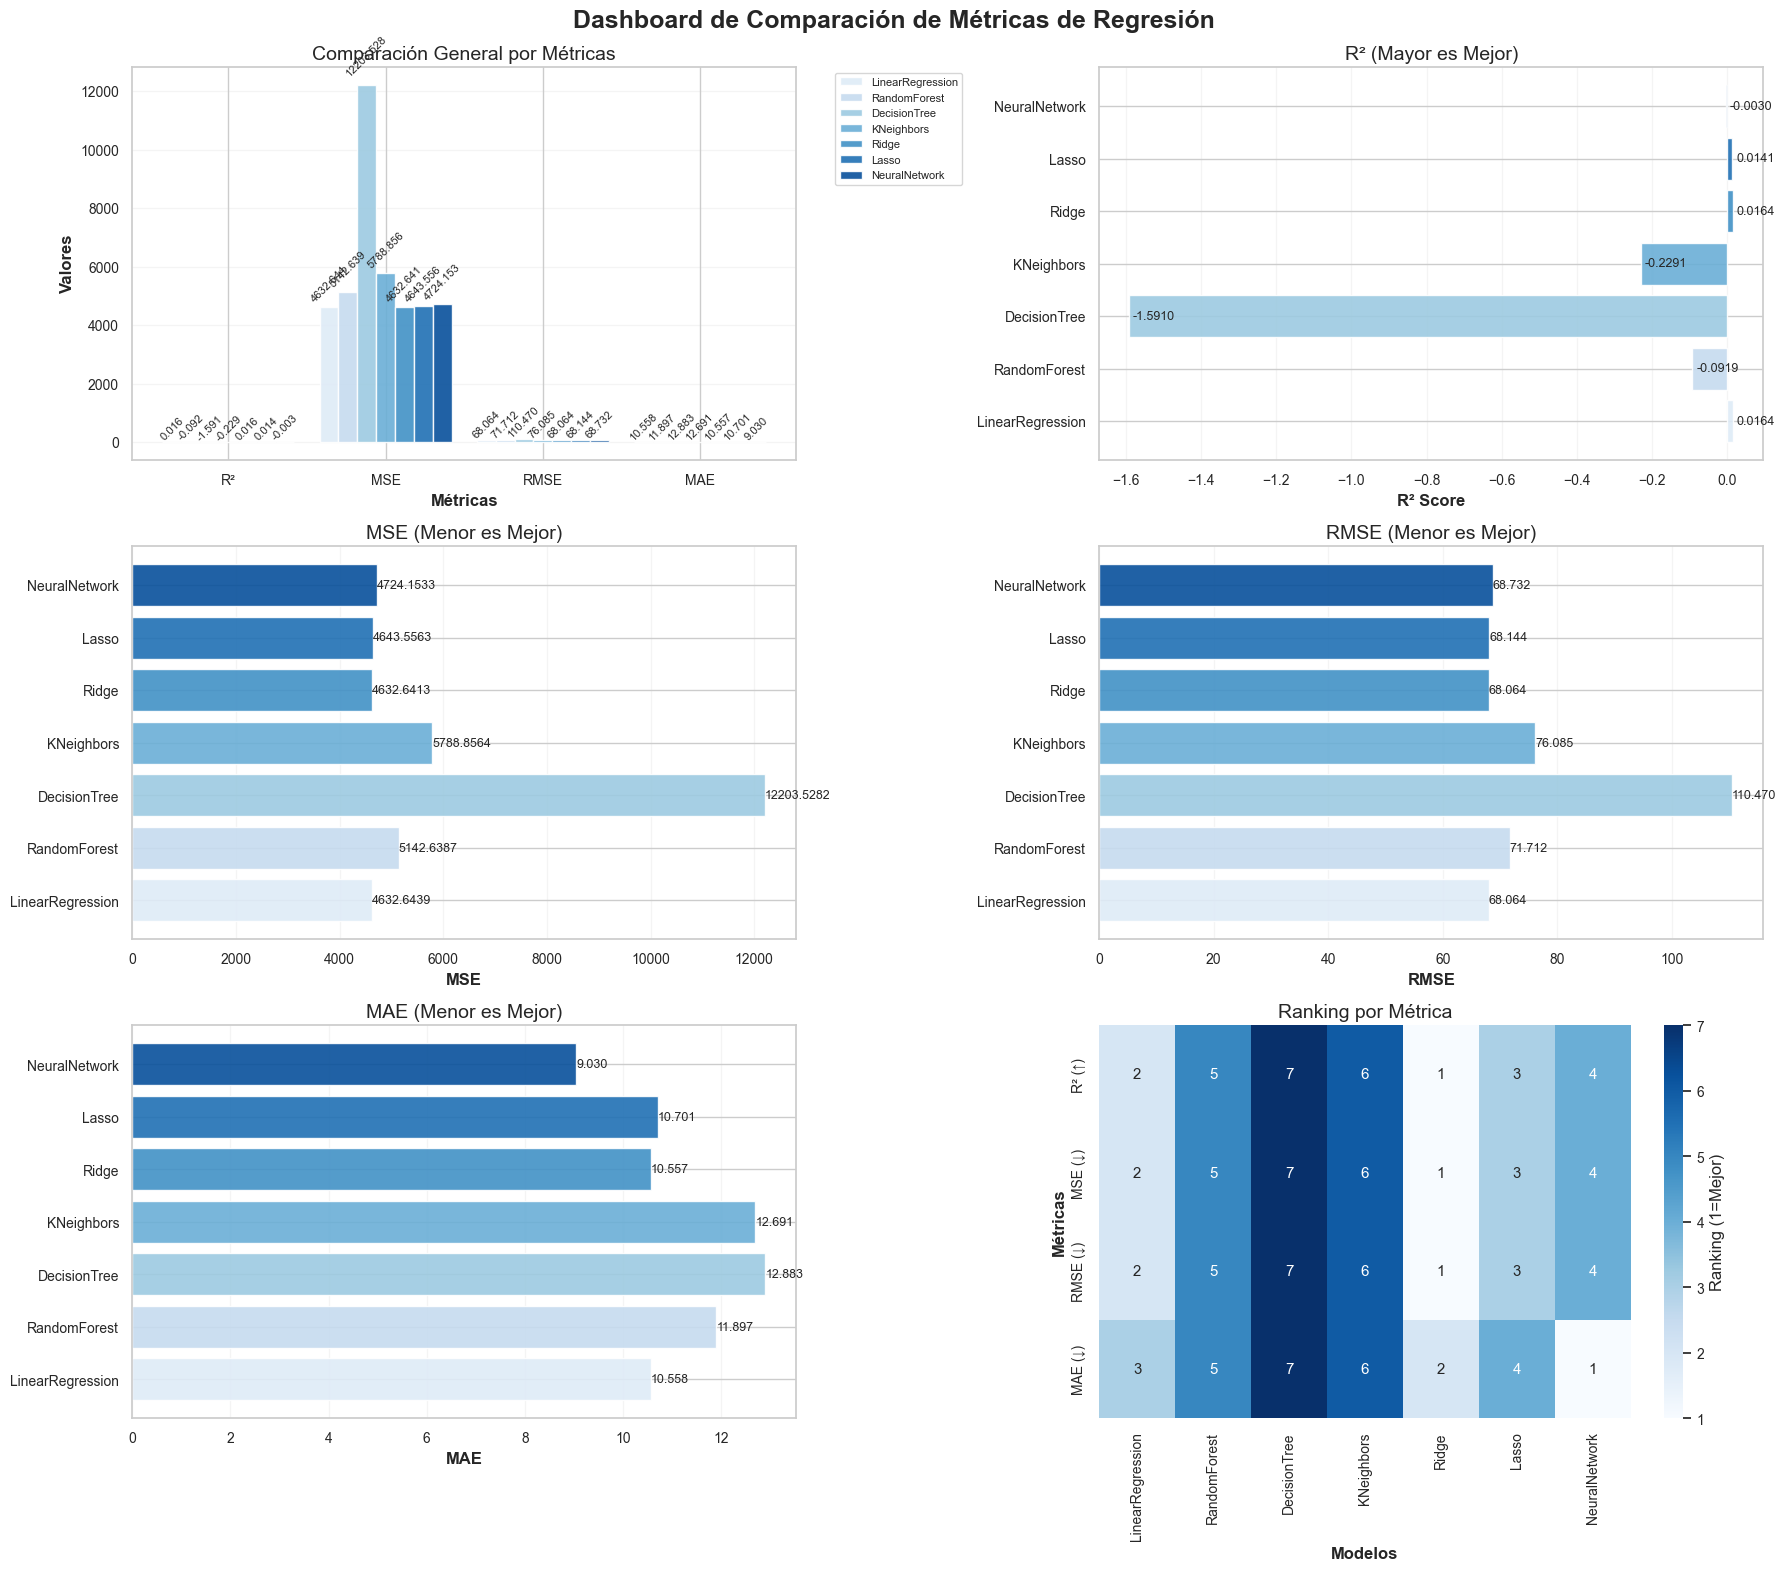

In [16]:
# Configurar figura con múltiples subplots (ahora 3x2 para gráficos individuales)
fig, axes = plt.subplots(3, 2, figsize=(18, 16), gridspec_kw={'height_ratios': [1, 1, 1]})
fig.suptitle('Dashboard de Comparación de Métricas de Regresión', fontsize=18, fontweight='bold')

# Preparar datos
models_names = list(test_metrics_results.keys())
# Paleta de Colores
colors = sns.color_palette("Blues", len(models_names))

# Barras comparativas Generales
ax1 = axes[0, 0]
metrics_reg = ['R²', 'MSE', 'RMSE', 'MAE']
x_pos = np.arange(len(metrics_reg))
width = 0.12

for i, (name, color) in enumerate(zip(models_names, colors)):
    values = [test_metrics_results[name][metric] for metric in metrics_reg]
    bars = ax1.bar(x_pos + i * width, values, width, label=name, color=color, alpha=0.9, edgecolor='white')
    
    # Etiquetas en barras
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.02, f'{val:.3f}', 
                 ha='center', va='bottom', fontsize=8, rotation=45)

ax1.set_xlabel('Métricas', fontweight='bold')
ax1.set_ylabel('Valores', fontweight='bold')
ax1.set_title('Comparación General por Métricas')
ax1.set_xticks(x_pos + width * (len(models_names) - 1) / 2)
ax1.set_xticklabels(metrics_reg, rotation=0)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.2, axis='y')

# Gráfico 02: R² Score
ax2 = axes[0, 1]
r2_scores = [test_metrics_results[name]['R²'] for name in models_names]
bars2 = ax2.barh(models_names, r2_scores, color=colors, alpha=0.9)
ax2.set_xlabel('R² Score', fontweight='bold')
ax2.set_title('R² (Mayor es Mejor)')
ax2.grid(True, alpha=0.2, axis='x')
for bar, score in zip(bars2, r2_scores):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{score:.4f}', 
             ha='left', va='center', fontsize=9)

# Gráfico 03: MSE 
ax3 = axes[1, 0]
mse_scores = [test_metrics_results[name]['MSE'] for name in models_names]
bars3 = ax3.barh(models_names, mse_scores, color=colors, alpha=0.9)
ax3.set_xlabel('MSE', fontweight='bold')
ax3.set_title('MSE (Menor es Mejor)')
ax3.grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars3, mse_scores):
    ax3.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
             ha='left', va='center', fontsize=9)

# Gráfico 04: RMSE
ax4 = axes[1, 1]
rmse_scores = [test_metrics_results[name]['RMSE'] for name in models_names]
bars4 = ax4.barh(models_names, rmse_scores, color=colors, alpha=0.9)
ax4.set_xlabel('RMSE', fontweight='bold')
ax4.set_title('RMSE (Menor es Mejor)')
ax4.grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars4, rmse_scores):
    ax4.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
             ha='left', va='center', fontsize=9)

# Gráfico 05: MAE
ax5 = axes[2, 0]
mae_scores = [test_metrics_results[name]['MAE'] for name in models_names]
bars5 = ax5.barh(models_names, mae_scores, color=colors, alpha=0.9)
ax5.set_xlabel('MAE', fontweight='bold')
ax5.set_title('MAE (Menor es Mejor)')
ax5.grid(True, alpha=0.2, axis='x')
for bar, val in zip(bars5, mae_scores):
    ax5.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
             ha='left', va='center', fontsize=9)

# Gráfico 06: Heatmap
ax6 = axes[2, 1]
comparison_df = pd.DataFrame(test_metrics_results).T
ranking_matrix = []
for metric in metrics_reg:
    if metric == 'R²':
        ranked = comparison_df[metric].rank(ascending=False)
    else:
        ranked = comparison_df[metric].rank(ascending=True)
    ranking_matrix.append(ranked.values)

ranking_df = pd.DataFrame(ranking_matrix, index=[f'{m} {"(↑)" if m=="R²" else "(↓)"}' for m in metrics_reg], columns=models_names)

sns.heatmap(ranking_df, annot=True, fmt='.0f', cmap='Blues', ax=ax6, cbar_kws={'label': 'Ranking (1=Mejor)'})
ax6.set_title('Ranking por Métrica')
ax6.set_xlabel('Modelos', fontweight='bold')
ax6.set_ylabel('Métricas', fontweight='bold')

plt.tight_layout()
plt.show()


In [17]:
# Resumen Mejorado con Ranking Promedio
print("\nResumen de los Mejores Modelos")
best_models = {}
for metric in metrics_reg:
    if metric == 'R²':
        best = max(test_metrics_results.items(), key=lambda x: x[1][metric])
    else:
        best = min(test_metrics_results.items(), key=lambda x: x[1][metric])
    print(f"Mejor {metric:>4} {'(Mayor)':<7}: {best[0]:<20} = {best[1][metric]:.4f}")
    best_models[metric] = best[0]

# Ranking Promedio
avg_ranks = ranking_df.mean().sort_values()
print("\nRanking Promedio (Menor = Mejor General):")
for model, rank in avg_ranks.items():
    print(f"{model:<20}: {rank:.2f}")


Resumen de los Mejores Modelos
Mejor   R² (Mayor): Ridge                = 0.0164
Mejor  MSE (Mayor): Ridge                = 4632.6413
Mejor RMSE (Mayor): Ridge                = 68.0635
Mejor  MAE (Mayor): NeuralNetwork        = 9.0296

Ranking Promedio (Menor = Mejor General):
Ridge               : 1.25
LinearRegression    : 2.25
Lasso               : 3.25
NeuralNetwork       : 3.25
RandomForest        : 5.00
KNeighbors          : 6.00
DecisionTree        : 7.00
